# Корпуса: blending классики и MLP

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

Бонус из задания: **blending нескольких моделей**.

Здесь не подбираю хитрые веса на validation -- это быстро превратилось бы в еще один слой overfit. Сравниваю простые фиксированные soft-vote blends по сохраненным probabilities:

1. `LogReg` + `RF` ~~+ `LightGBM`~~;
2. `LogReg` + `RF` ~~+ `LightGBM`~~ + `MLP`.

Все predictions относятся к одному и тому же hold-out validation split, т.к. в [01_MLP_architecture.ipynb](/notebooks/01_MLP_architecture.ipynb) и [02_classical_models.ipynb](/hws/notebooks/02_classical_models.ipynb) используется одинаковый `SEED`, `VAL_SIZE` и исходный порядок объектов.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


cwd = Path.cwd().resolve()
if (cwd / "hws").exists():
    HWS_DIR = cwd / "hws"
elif cwd.name == "notebooks" and cwd.parent.name == "hws":
    HWS_DIR = cwd.parent
else:
    HWS_DIR = cwd

OUTPUT_DIR = HWS_DIR / "output"
sns.set_theme(style="whitegrid")


_`LGBM` крашит ядро, пока закомментирую, но, чисто в теории, оно должно нормально отрабатывать:_

In [2]:
def load_probs(path):
    data = np.load(path)
    return data["y_true"], data["probabilities"]


def metrics(y_true, probabilities):
    y_pred = probabilities.argmax(axis=1)
    return {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "y_pred": y_pred,
    }


def run_blends(dataset_name, slug):
    model_files = {
        "Logistic Regression": OUTPUT_DIR / f"{slug}_logistic_regression_validation_predictions.npz",
        "Random Forest": OUTPUT_DIR / f"{slug}_random_forest_validation_predictions.npz",
        # "LightGBM": OUTPUT_DIR / f"{slug}_lightgbm_validation_predictions.npz",
        "MLP": OUTPUT_DIR / f"{slug}_mlp_validation_predictions.npz",
    }

    loaded = {name: load_probs(path) for name, path in model_files.items()}
    y_true = loaded["MLP"][0]
    rows = []

    for name, (_, probabilities) in loaded.items():
        row = metrics(y_true, probabilities)
        row.update({"dataset": dataset_name, "model": name})
        rows.append(row)

    # classical_probs = np.mean([loaded[name][1] for name in ["Logistic Regression", "Random Forest", "LightGBM"]], axis=0)
    # all_probs = np.mean([loaded[name][1] for name in ["Logistic Regression", "Random Forest", "LightGBM", "MLP"]], axis=0)
    classical_probs = np.mean([loaded[name][1] for name in ["Logistic Regression", "Random Forest"]], axis=0)
    all_probs = np.mean([loaded[name][1] for name in ["Logistic Regression", "Random Forest", "MLP"]], axis=0)

    for name, probabilities in [
        ("Blend: classical", classical_probs),
        ("Blend: classical + MLP", all_probs),
    ]:
        row = metrics(y_true, probabilities)
        row.update({"dataset": dataset_name, "model": name})
        rows.append(row)

    result = pd.DataFrame(rows)
    result = result[["dataset", "model", "balanced_accuracy", "macro_f1", "macro_precision", "macro_recall", "y_pred"]]
    return result, y_true

In [3]:
mnist_blending, mnist_y = run_blends("MNIST", "mnist")
fashion_blending, fashion_y = run_blends("Fashion-MNIST", "fashion")
blending_results = pd.concat([mnist_blending, fashion_blending], ignore_index=True)
blending_results.drop(columns="y_pred").to_csv(OUTPUT_DIR / "blending_results.csv", index=False)
blending_results.drop(columns="y_pred")

,dataset,model,balanced_accuracy,macro_f1,macro_precision,macro_recall
0,MNIST,Logistic Regression,0.907715,0.907542,0.907541,0.907715
1,MNIST,Random Forest,0.957023,0.957068,0.957162,0.957023
2,MNIST,MLP,0.967103,0.967164,0.967386,0.967103
3,MNIST,Blend: classical,0.925221,0.925128,0.925149,0.925221
4,MNIST,Blend: classical + MLP,0.962822,0.962938,0.963174,0.962822
5,Fashion-MNIST,Logistic Regression,0.846700,0.846463,0.846504,0.846700
6,Fashion-MNIST,Random Forest,0.873500,0.872230,0.872515,0.873500
7,Fashion-MNIST,MLP,0.878200,0.878856,0.881758,0.878200
8,Fashion-MNIST,Blend: classical,0.865600,0.864678,0.864464,0.865600
9,Fashion-MNIST,Blend: classical + MLP,0.880400,0.880145,0.880582,0.880400


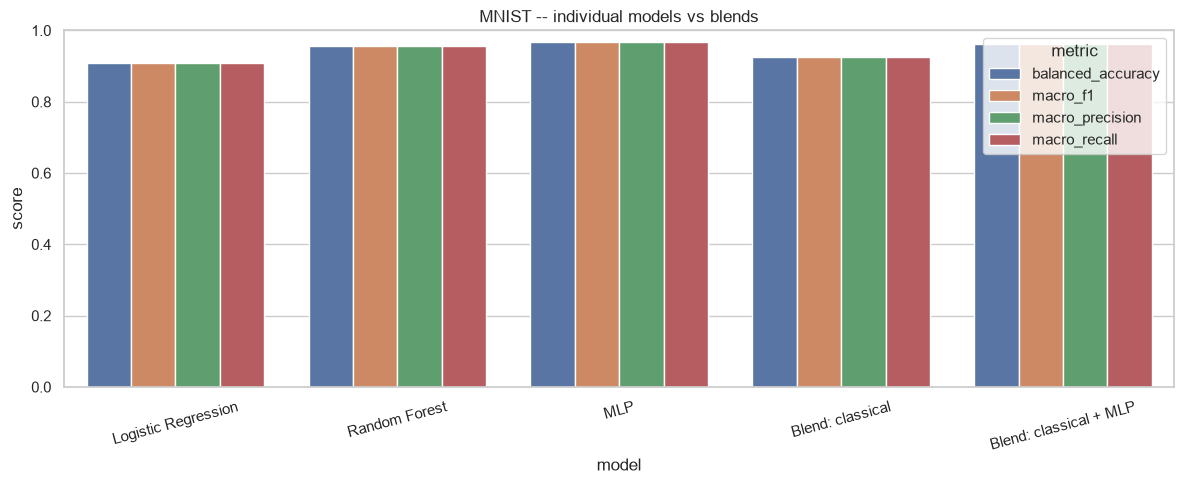

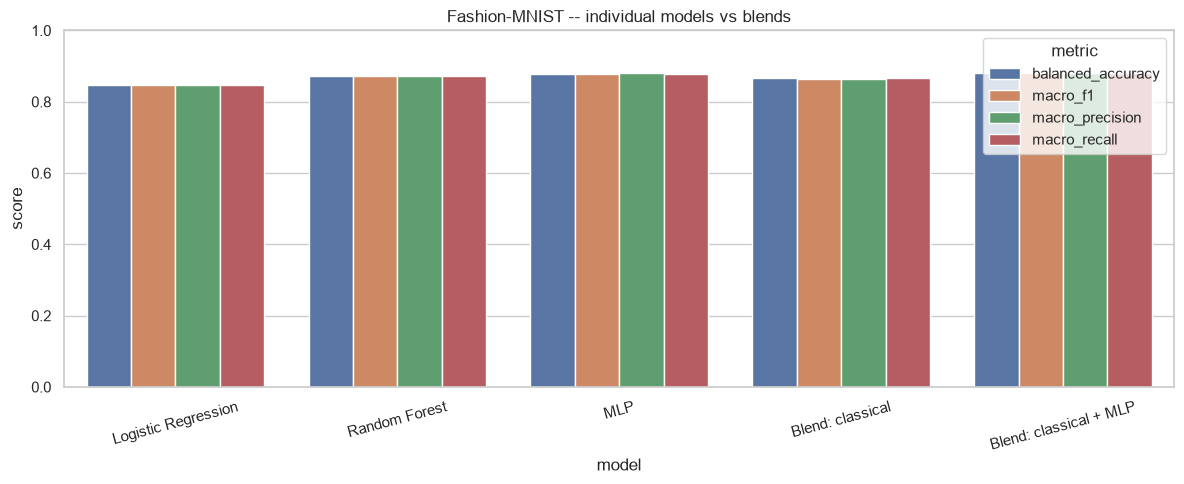

In [4]:
plot_data = blending_results.drop(columns="y_pred").melt(
    id_vars=["dataset", "model"],
    value_vars=["balanced_accuracy", "macro_f1", "macro_precision", "macro_recall"],
    var_name="metric",
    value_name="score",
)

for dataset_name in ["MNIST", "Fashion-MNIST"]:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_data[plot_data.dataset == dataset_name], x="model", y="score", hue="metric")
    plt.ylim(0, 1)
    plt.title(f"{dataset_name} -- individual models vs blends")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{dataset_name.lower().replace('-', '_')}_blending_metrics.png", dpi=170, bbox_inches="tight")
    plt.show()


In [5]:
def plot_best_blend(result, y_true, class_names, slug):
    best = result.sort_values("balanced_accuracy", ascending=False).iloc[0]
    cm = confusion_matrix(y_true, best.y_pred, normalize="true")
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size":8}, vmin=0, vmax=1)
    plt.title(f"{slug} -- {best.model}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{slug}_best_blend_confusion_matrix.png", dpi=180, bbox_inches="tight")
    plt.show()


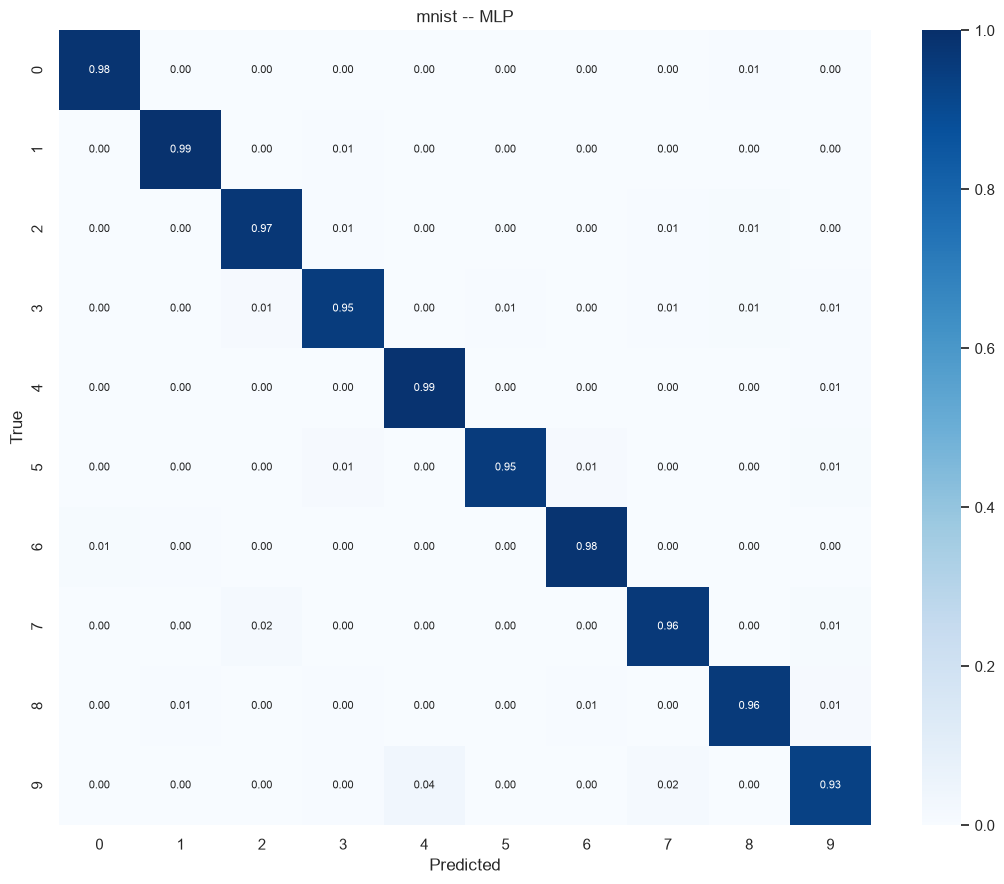

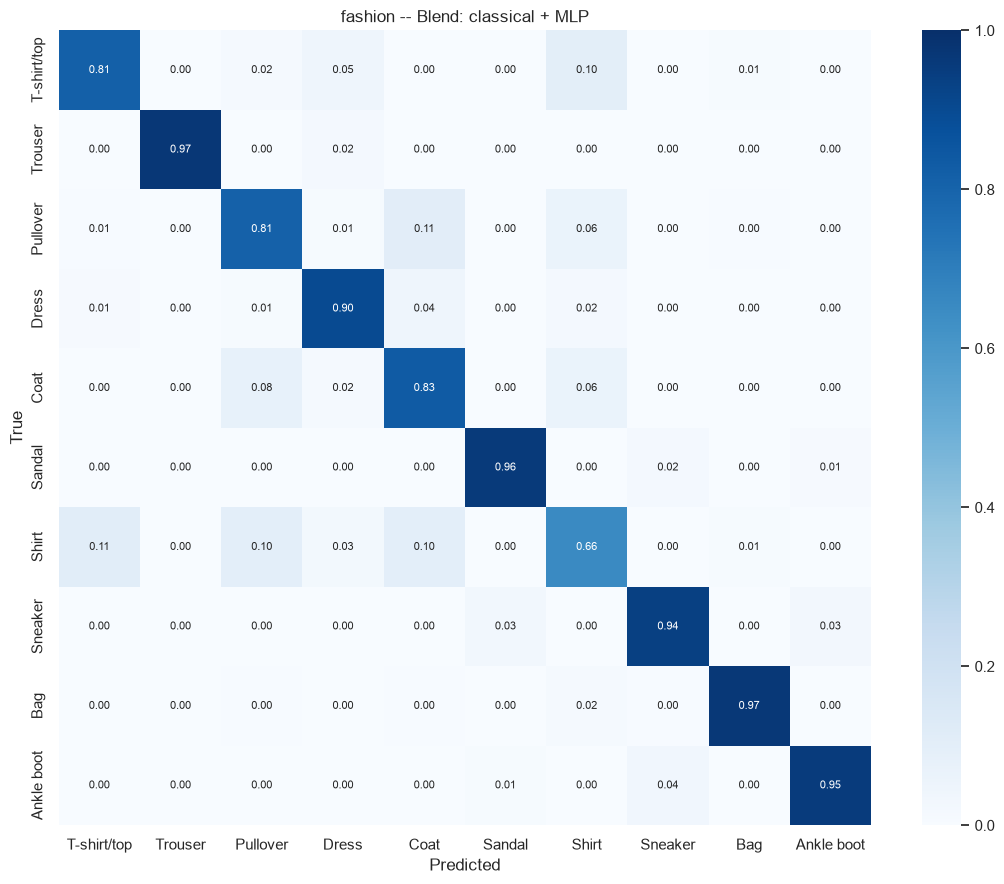

In [6]:
plot_best_blend(mnist_blending, mnist_y, [str(i) for i in range(10)], "mnist")
plot_best_blend(
    fashion_blending,
    fashion_y,
    ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"],
    "fashion",
)

Блендинг прироста не дал.

## Обновление численных результатов для отчета

Последняя техническая ячейка собирает короткую таблицу из уже сохраненных CSV. Сам `report.tex` остается ручным и читаемым, а числа после полного запуска не приходится переносить руками.


In [7]:
required = [
    OUTPUT_DIR / "mlp_final_results.csv",
    OUTPUT_DIR / "mlp_cv_results.csv",
    OUTPUT_DIR / "model_comparison.csv",
    OUTPUT_DIR / "blending_results.csv",
    OUTPUT_DIR / "synthetic_grid_results.csv",
]

if all(path.exists() for path in required):
    final_mlp = pd.read_csv(OUTPUT_DIR / "mlp_final_results.csv")
    mlp_cv = pd.read_csv(OUTPUT_DIR / "mlp_cv_results.csv")
    comparison = pd.read_csv(OUTPUT_DIR / "model_comparison.csv")
    blends = pd.read_csv(OUTPUT_DIR / "blending_results.csv")
    synthetic = pd.read_csv(OUTPUT_DIR / "synthetic_grid_results.csv")

    lines = [r"\section*{Численные результаты после полного запуска}"]

    for dataset in ["MNIST", "Fashion-MNIST"]:
        final = final_mlp[final_mlp.dataset == dataset].iloc[0]
        cv_part = mlp_cv[mlp_cv.dataset == dataset]
        best_validation = comparison[comparison.dataset == dataset].sort_values("balanced_accuracy", ascending=False).iloc[0]
        best_blend = blends[blends.dataset == dataset].sort_values("balanced_accuracy", ascending=False).iloc[0]
        lines += [
            f"\\textbf{{{dataset}}}: final MLP test balanced accuracy = {final.test_balanced_accuracy:.4f}, "
            f"macro-F1 = {final.test_macro_f1:.4f}. "
            f"5-fold CV selected MLP: {cv_part.balanced_accuracy.mean():.4f} $\\pm$ {cv_part.balanced_accuracy.std():.4f}. "
            f"Лучшая validation model: {best_validation['model']} ({best_validation.balanced_accuracy:.4f}). "
            f"Лучший fixed-weight blend: {best_blend['model']} ({best_blend.balanced_accuracy:.4f}).\\par"
        ]

    lines += [
        r"\begin{center}",
        r"\small",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{llrrrrr}",
        r"\toprule",
        r"Dataset & Model & BalAcc & F1 & Precision & Recall & Time, s \\",
        r"\midrule",
    ]
    for row in comparison.itertuples(index=False):
        model = str(row.model).replace("_", r"\_")
        lines.append(
            f"{row.dataset} & {model} & {row.balanced_accuracy:.4f} & {row.macro_f1:.4f} & "
            f"{row.macro_precision:.4f} & {row.macro_recall:.4f} & {row.fit_time_sec:.1f} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}%", r"}", r"\end{center}"]

    best_syn = synthetic.sort_values("test_mse").iloc[0]
    lines.append(
        f"Периодическая синтетическая функция: лучшая точка heatmap depth={int(best_syn.depth)}, "
        f"width={int(best_syn.width)}, MSE={best_syn.test_mse:.6f}."
    )
    (OUTPUT_DIR / "generated_results.tex").write_text("\n".join(lines), encoding="utf-8")
    print("output/generated_results.tex updated")
else:
    print("Для generated_results.tex сначала выполните ноутбуки 01--04 по порядку.")


output/generated_results.tex updated


## Выводы

Equal-weight soft voting -- aka baseline. 

Он прироста не дал: коррелированные ошибки сильных моделей нельзя исправить одним усреднением.